In [123]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [124]:
BASE_DIR = Path('/mimer/NOBACKUP/groups/naiss2024-6-297/cache/bertopic_bootstrapped')
MIN_TOPIC_SIZES = [5, 10, 15, 20, 25]

# Load all pilot discovery summaries across min_topic_size values
all_rows = []
for mts in MIN_TOPIC_SIZES:
    pilot_dir = BASE_DIR / f'pilot_discovery_{mts}'
    files = sorted(pilot_dir.glob('discovery_summary_bootstrap_*.json'))
    print(f'min_topic_size={mts:>3d}: {len(files):>2d}/10 bootstraps in {pilot_dir.name}/')
    for path in files:
        with open(path, 'r') as f:
            rec = json.load(f)
        rec['min_topic_size'] = mts
        all_rows.append(rec)

df_all = pd.DataFrame(all_rows)
df_all['outlier_rate'] = df_all['outlier_sentence_count'] / df_all['n_sentences']
print(f'\nTotal records loaded: {len(df_all)}')
df_all.head()

min_topic_size=  5: 10/10 bootstraps in pilot_discovery_5/
min_topic_size= 10: 10/10 bootstraps in pilot_discovery_10/
min_topic_size= 15: 10/10 bootstraps in pilot_discovery_15/
min_topic_size= 20: 10/10 bootstraps in pilot_discovery_20/
min_topic_size= 25: 10/10 bootstraps in pilot_discovery_25/

Total records loaded: 50


,bootstrap_idx,n_stories,n_sentences,discovered_topics_excl_outlier,discovered_topics_incl_outlier,outlier_sentence_count,min_topic_size,outlier_rate
0,0,720,4183,137,138,979,5,0.234043
1,1,720,4180,137,138,925,5,0.221292
2,2,720,4182,141,142,934,5,0.223338
3,3,720,4183,144,145,1056,5,0.252450
4,4,720,4178,142,143,964,5,0.230732


In [ ]:
# For each min_topic_size: mean ± std of key metrics across bootstraps

metrics = ['discovered_topics_excl_outlier', 'outlier_sentence_count', 'outlier_rate']

summary = (
    df_all.groupby('min_topic_size')[metrics]
    .agg(['mean', 'std', 'min', 'max'])
)
# Flatten multi-level columns for readability
summary.columns = [f'{m}_{stat}' for m, stat in summary.columns]
summary = summary.round(3)
summary

,discovered_topics_excl_outlier_mean,discovered_topics_excl_outlier_std,discovered_topics_excl_outlier_min,discovered_topics_excl_outlier_max,outlier_sentence_count_mean,outlier_sentence_count_std,outlier_sentence_count_min,outlier_sentence_count_max,outlier_rate_mean,outlier_rate_std,outlier_rate_min,outlier_rate_max
min_topic_size,,,,,,,,,,,,
5,138.7,4.001,130,144,950.9,47.894,890,1056,0.227,0.011,0.213,0.252
10,84.6,4.274,80,95,799.6,99.878,715,1045,0.191,0.024,0.171,0.250
15,63.2,3.155,57,67,762.6,99.515,604,914,0.182,0.024,0.144,0.219
20,52.9,1.524,51,55,779.0,59.642,698,874,0.186,0.014,0.167,0.209
25,49.9,0.568,49,51,866.2,80.578,711,969,0.207,0.019,0.170,0.232


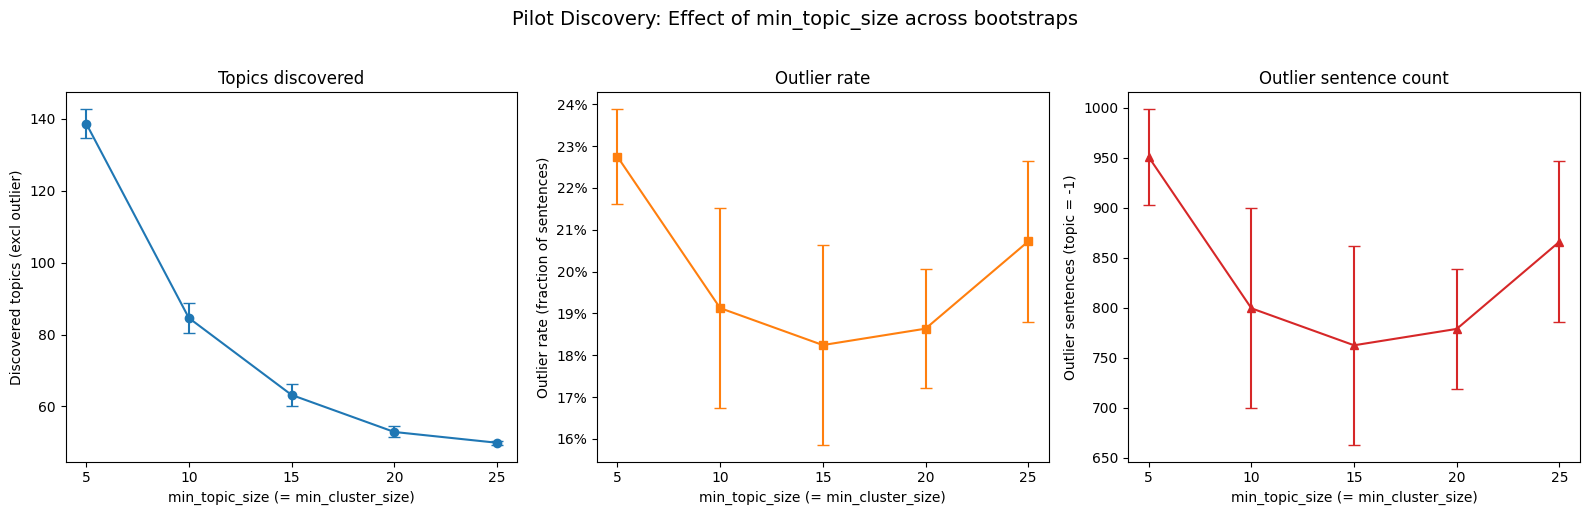

In [126]:
# ── Visual comparison across min_topic_size ──

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Number of discovered topics (excl outlier)
ax = axes[0]
grouped = df_all.groupby('min_topic_size')['discovered_topics_excl_outlier']
means = grouped.mean()
stds = grouped.std()
ax.errorbar(means.index, means.values, yerr=stds.values, fmt='o-', capsize=4, color='tab:blue')
ax.set_xlabel('min_topic_size (= min_cluster_size)')
ax.set_ylabel('Discovered topics (excl outlier)')
ax.set_title('Topics discovered')
ax.set_xticks(MIN_TOPIC_SIZES)

# 2) Outlier rate
ax = axes[1]
grouped = df_all.groupby('min_topic_size')['outlier_rate']
means = grouped.mean()
stds = grouped.std()
ax.errorbar(means.index, means.values, yerr=stds.values, fmt='s-', capsize=4, color='tab:orange')
ax.set_xlabel('min_topic_size (= min_cluster_size)')
ax.set_ylabel('Outlier rate (fraction of sentences)')
ax.set_title('Outlier rate')
ax.set_xticks(MIN_TOPIC_SIZES)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# 3) Outlier count
ax = axes[2]
grouped = df_all.groupby('min_topic_size')['outlier_sentence_count']
means = grouped.mean()
stds = grouped.std()
ax.errorbar(means.index, means.values, yerr=stds.values, fmt='^-', capsize=4, color='tab:red')
ax.set_xlabel('min_topic_size (= min_cluster_size)')
ax.set_ylabel('Outlier sentences (topic = -1)')
ax.set_title('Outlier sentence count')
ax.set_xticks(MIN_TOPIC_SIZES)

fig.suptitle('Pilot Discovery: Effect of min_topic_size across bootstraps', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## Per-setting topic inspection
Pick a `min_topic_size` and bootstrap to inspect top words, topic sizes, and outlier content.

**Decision criteria:**
1. **Topic count** — enough to capture scene/action types, not so many it's fragmented by character names
2. **Outlier rate** — low enough that most sentences are assigned, but not forced into bad clusters
3. **Topic interpretability** — top words should reflect scenes, actions, emotions — not just proper nouns
4. **Bootstrap stability** — topic counts should be similar across bootstraps (low std)
5. **nr_topics range** — the discovered topic count sets the **upper bound** for `nr_topics` in full training

In [127]:
# ── Inspect topics for a specific min_topic_size + bootstrap ──
# Change these to explore different settings
MTS_TO_INSPECT = 10
BOOTSTRAP_TO_INSPECT = 0

pilot_dir = BASE_DIR / f'pilot_discovery_{MTS_TO_INSPECT}'
topic_info_path = pilot_dir / f'topic_info_bootstrap_{BOOTSTRAP_TO_INSPECT:02d}.csv'

if not topic_info_path.exists():
    print(f'File not found: {topic_info_path}')
    print('Jobs may still be running. Check with: squeue -u $USER')
else:
    topic_info = pd.read_csv(topic_info_path)
    print(f'min_topic_size={MTS_TO_INSPECT}, bootstrap={BOOTSTRAP_TO_INSPECT}')
    print(f'Columns: {list(topic_info.columns)}')
    print(f'Total topics (incl outlier): {len(topic_info)}')

    # Top topics by size (excluding outlier topic -1)
    topics_main = topic_info[topic_info['Topic'] != -1].sort_values('Count', ascending=False)
    print(f'Topics (excl outlier): {len(topics_main)}')
    topics_main.head(20)

min_topic_size=10, bootstrap=0
Columns: ['Topic', 'Count', 'Name', 'Representation', 'Representative_Docs']
Total topics (incl outlier): 87
Topics (excl outlier): 86


In [128]:
# ── Show top words per topic for the inspected setting ──

def parse_top_words(row, max_words=10):
    """Extract readable top words from BERTopic topic_info row."""
    if 'Representation' in row and pd.notna(row['Representation']):
        txt = str(row['Representation']).strip('[]')
        words = [w.strip().strip("'").strip('"') for w in txt.split(',') if w.strip()]
        return ', '.join(words[:max_words])
    if 'Name' in row and pd.notna(row['Name']):
        name = str(row['Name'])
        if '_' in name:
            return ', '.join(name.split('_')[1:1+max_words])
        return name
    return ''

if topic_info_path.exists():
    inspect_cols = ['Topic', 'Count']
    if 'Name' in topic_info.columns:
        inspect_cols.append('Name')

    topics_words = topics_main.copy()
    topics_words['TopWords'] = topics_words.apply(parse_top_words, axis=1)

    print(f'Top 30 topics by size (min_topic_size={MTS_TO_INSPECT}, bootstrap={BOOTSTRAP_TO_INSPECT}):')
    with pd.option_context('display.max_colwidth', None):
        display(topics_words[inspect_cols + ['TopWords']].head(30))

Top 30 topics by size (min_topic_size=10, bootstrap=0):


,Topic,Count,Name,TopWords
1,0,317,0_people_crowd_image_of,"people, crowd, image, of, scene, some, with, the, images, sequence"
2,1,114,1_ben_dog_cameron_lin,"ben, dog, cameron, lin, floor, small, kitchen, tried, living, to"
3,2,94,2_shea_christian_bradley_suit,"shea, christian, bradley, suit, books, his, conversation, discussion, blue, women"
4,3,84,3_office_masked_employees_robert,"office, masked, employees, robert, vault, val, hostages, desks, fear, workers"
5,4,77,4_mel_heath_ruins_bloodied,"mel, heath, ruins, bloodied, charred, children, destruction, blood, home, house"
6,5,76,5_diner_coffee_palm_two,"diner, coffee, palm, two, booth, women, entrance, sign, leather, cardigan"
7,6,75,6_james_wheelchair_phone_door,"james, wheelchair, phone, door, his, room, he, receiver, telephone, darkness"
8,7,72,7_soldiers_frederic_helicopter_laurence,"soldiers, frederic, helicopter, laurence, soldier, fire, night, camp, albert, by"
9,8,71,8_sheriff_men_cowboy_armed,"sheriff, men, cowboy, armed, gun, ready, rifle, smoke, outside, shotgun"
10,9,69,9_she_cottage_axe_house,"she, cottage, axe, house, stone, clothesline, wood, her, well, field"


In [129]:
# ── Outlier topic -1 inspection ──

if topic_info_path.exists():
    outlier_row = topic_info[topic_info['Topic'] == -1]

    if outlier_row.empty:
        print('No topic -1 found.')
    else:
        display(outlier_row)

        if 'Count' in outlier_row.columns:
            outlier_count = int(outlier_row['Count'].iloc[0])
            total_chunks = int(topic_info['Count'].sum())
            print(f'Outlier: {outlier_count} / {total_chunks} sentences ({outlier_count/total_chunks:.2%})')

        rep_col = None
        for c in ['Representative_Docs', 'Representative Docs']:
            if c in outlier_row.columns:
                rep_col = c
                break
        if rep_col is not None:
            print(f'\nRepresentative outlier content:')
            print(outlier_row[rep_col].iloc[0])
        else:
            print('\nNo representative-doc column in topic_info.')

,Topic,Count,Name,Representation,Representative_Docs
0,-1,724,-1_the_to_he_of,"['the', 'to', 'he', 'of', 'and', 'his', 'in', ...","[""In the aftermath of the confrontation , the ..."


Outlier: 724 / 4183 sentences (17.31%)

Representative outlier content:
["In the aftermath of the confrontation , the crowd has dispersed , and the town square is quiet once again . The man from the beginning of the story is now standing alone , his eyes still fixed on something off-screen . His expression is still serious , but there 's a sense of resolve to it now , as if he 's made a decision .", 'Angelina stood alone in a dimly lit room , her eyes closed in deep thought . She appeared lost in her emotions , her hand covering her mouth . The room was filled with the tension of anticipation . As she opened her eyes , a group of people gathered around a table , engrossed in conversation . Jonny , Renoly , and Matthew stood together , each holding drinks , while Fisher observed from a distance . The atmosphere was intense , suggesting an important discussion was underway .', 'A young man with tousled brown hair sits across from the blonde woman at what appears to be a dining table . Bo

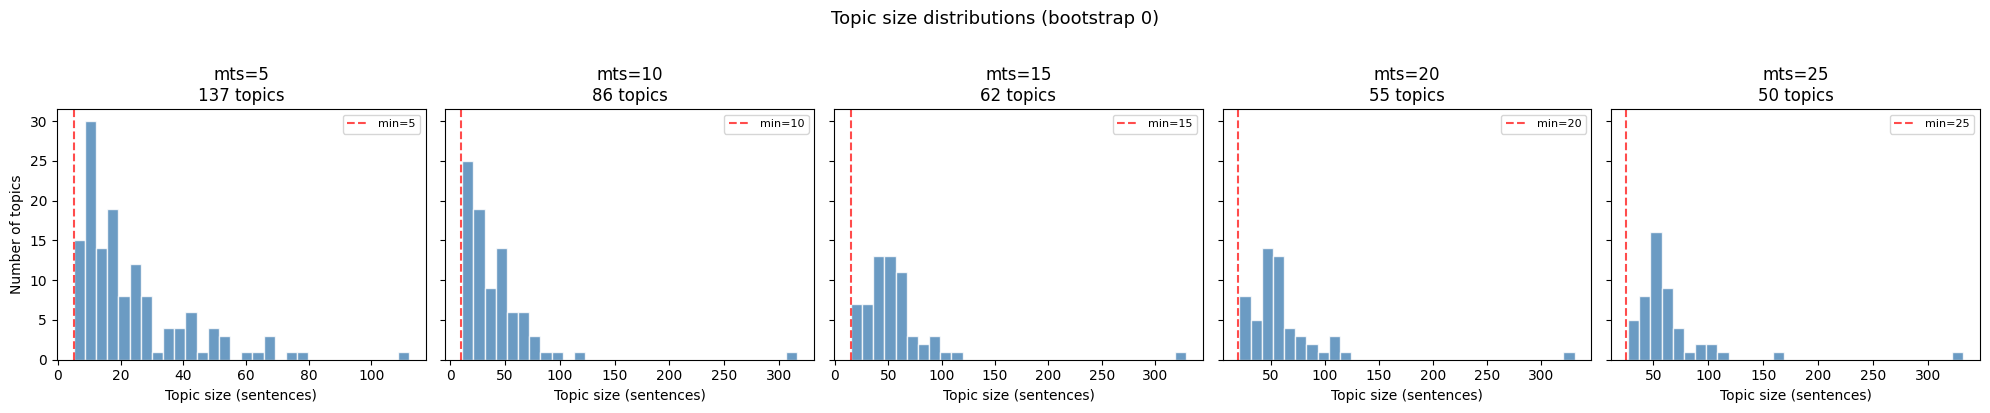

In [130]:
# ── Compare topic size distributions across min_topic_size settings ──
# For each setting, show the distribution of topic sizes (how big is each topic?)

fig, axes = plt.subplots(1, len(MIN_TOPIC_SIZES), figsize=(4 * len(MIN_TOPIC_SIZES), 4), sharey=True)
bootstrap_to_compare = 0

for i, mts in enumerate(MIN_TOPIC_SIZES):
    ax = axes[i]
    ti_path = BASE_DIR / f'pilot_discovery_{mts}' / f'topic_info_bootstrap_{bootstrap_to_compare:02d}.csv'
    if not ti_path.exists():
        ax.set_title(f'mts={mts}\n(not ready)')
        continue
    ti = pd.read_csv(ti_path)
    sizes = ti.loc[ti['Topic'] != -1, 'Count'].values
    ax.hist(sizes, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'mts={mts}\n{len(sizes)} topics')
    ax.set_xlabel('Topic size (sentences)')
    if i == 0:
        ax.set_ylabel('Number of topics')
    ax.axvline(x=mts, color='red', linestyle='--', alpha=0.7, label=f'min={mts}')
    ax.legend(fontsize=8)

fig.suptitle(f'Topic size distributions (bootstrap {bootstrap_to_compare})', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

In [131]:
# ── Decision summary ──
# Print a clean table mapping min_topic_size → recommended nr_topics range

print('='*70)
print('DECISION SUMMARY: min_topic_size → nr_topics range for full training')
print('='*70)
print()
print(f'{"mts":>5s}  {"topics_mean":>12s}  {"topics_std":>10s}  {"outlier%_mean":>13s}  {"recommended nr_topics upper bound":>35s}')
print('-'*70)

for mts in MIN_TOPIC_SIZES:
    subset = df_all[df_all['min_topic_size'] == mts]
    if subset.empty:
        print(f'{mts:>5d}  {"(no data)":>12s}')
        continue
    t_mean = subset['discovered_topics_excl_outlier'].mean()
    t_std = subset['discovered_topics_excl_outlier'].std()
    o_mean = subset['outlier_rate'].mean()
    # Upper bound for nr_topics: floor of (mean - 1*std) to stay safely below discovered count
    upper = int(np.floor(t_mean - t_std)) if not np.isnan(t_std) else int(t_mean)
    print(f'{mts:>5d}  {t_mean:>12.1f}  {t_std:>10.1f}  {o_mean:>12.1%}  {upper:>35d}')

print()
print('NOTE: nr_topics for full training must be < discovered topics,')
print('      otherwise BERTopic skips reduction entirely.')
print('      Use the upper bound above as the starting point for --nr-topics-start.')

DECISION SUMMARY: min_topic_size → nr_topics range for full training

  mts   topics_mean  topics_std  outlier%_mean    recommended nr_topics upper bound
----------------------------------------------------------------------
    5         138.7         4.0         22.7%                                  134
   10          84.6         4.3         19.1%                                   80
   15          63.2         3.2         18.2%                                   60
   20          52.9         1.5         18.6%                                   51
   25          49.9         0.6         20.7%                                   49

NOTE: nr_topics for full training must be < discovered topics,
      otherwise BERTopic skips reduction entirely.
      Use the upper bound above as the starting point for --nr-topics-start.
